# MAI202 — Assignment 1: House Price Prediction
### King County Housing Dataset
---

## Phase 0 — Setup

Before we can do anything useful, we need to bring in the tools. Think of this like setting up a workshop before starting a project — we need our measuring tape (numpy), our organizer (pandas), our drawing board (matplotlib), and our machine learning toolkit (scikit-learn and PyTorch). We also set a random seed so that every time we run this notebook, we get the same results — this makes our experiments repeatable and fair.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.10.0+cpu


---
## Phase 1 — Data Preparation

Raw data is rarely ready to feed into a model straight away. In this phase, we clean and shape the dataset so every model we build can use the exact same inputs on a level playing field.

Here is what we do and why:
- **Drop `id`** — it is just a row number, it carries zero information about price.
- **Parse `date`** — instead of throwing the date away entirely, we extract the sale year and sale month. The year can matter (market trends) and the month can matter (seasonal demand).
- **Drop `zipcode`** — zip codes look like numbers but they are really labels (zip 98178 is not "less than" 98199 in any meaningful way). Treating them as a number would mislead the model. Dropping is the simplest safe choice here; one-hot encoding is possible but adds ~70 extra columns.
- **Log-transform the target (`price`)** — house prices are right-skewed (a few mansions pull the average way up). Taking the log makes the distribution more symmetric and helps the neural network learn faster and more stably. We will convert predictions back to dollars at evaluation time.
- **Train / validation / test split** — 70 % training, 15 % validation, 15 % test. The validation set is used during training to catch overfitting; the test set is touched only once at the very end.
- **Feature scaling** — we fit a StandardScaler on the training data only, then apply it to validation and test. If we scaled using all data first, information about the test set would leak into training — that would be cheating.

In [52]:
df = pd.read_csv('data/kc_house_data.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


In [53]:
# ── Feature engineering ──────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['sale_year']  = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

drop_cols = ['id', 'date', 'zipcode']
df.drop(columns=drop_cols, inplace=True)

# Log-transform target
df['log_price'] = np.log1p(df['price'])

X = df.drop(columns=['price', 'log_price']).values.astype(np.float32)
y = df['log_price'].values.astype(np.float32)
y_raw = df['price'].values.astype(np.float32)   # kept for final metric display

feature_names = df.drop(columns=['price', 'log_price']).columns.tolist()
print(f'Features ({len(feature_names)}): {feature_names}')

# ── Split ─────────────────────────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test, yraw_trainval, yraw_test = train_test_split(
    X, y, y_raw, test_size=0.15, random_state=SEED)

X_train, X_val, y_train, y_val, yraw_train, yraw_val = train_test_split(
    X_trainval, y_trainval, yraw_trainval,
    test_size=0.15/0.85, random_state=SEED)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# ── PyTorch tensors ───────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train)
val_loader   = make_loader(X_val_s,   y_val,   shuffle=False)
test_loader  = make_loader(X_test_s,  y_test,  shuffle=False)

N_FEATURES = X_train_s.shape[1]
print(f'Number of input features: {N_FEATURES}')

Features (19): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month']
Train: 15129  Val: 3242  Test: 3242
Number of input features: 19


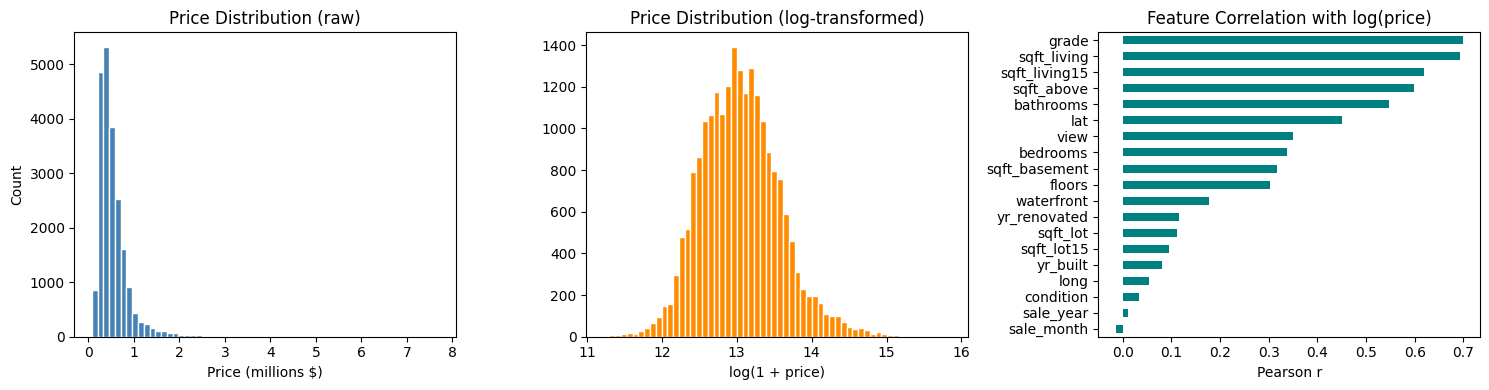

In [54]:
# ── Quick EDA plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['price'] / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price (millions $)')
axes[0].set_ylabel('Count')

axes[1].hist(df['log_price'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution (log-transformed)')
axes[1].set_xlabel('log(1 + price)')

corr = pd.DataFrame(X_train, columns=feature_names).corrwith(
    pd.Series(y_train, name='log_price')).sort_values()
corr.plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Feature Correlation with log(price)')
axes[2].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('plots_phase1_eda.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 2 — Deep Network Version A (No Generalization)
### Assignment Task 1a

Now we build our first neural network. Think of it like teaching someone to memorize answers rather than truly understand a subject. This network has no safety rails — it will learn the training data very well but will likely struggle on data it has never seen before. That "struggle" is called **overfitting**, and by plotting the training loss versus the validation loss over time, we can actually watch it happen. The diverging curves are the point — we need to see the problem before we can fix it in Phase 3.

In [55]:
# ── Shared evaluation helper ──────────────────────────────────────────────────
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds, actuals = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            total_loss += criterion(out, yb).item() * len(xb)
            preds.append(out.cpu().numpy())
            actuals.append(yb.cpu().numpy())
    preds   = np.concatenate(preds).flatten()
    actuals = np.concatenate(actuals).flatten()
    mse  = total_loss / len(loader.dataset)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actuals, preds)
    r2   = r2_score(actuals, preds)
    return mse, rmse, mae, r2, preds

def train_model(model, train_loader, val_loader,
                epochs=150, lr=1e-3, patience=None):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}
    best_val, no_improve = float('inf'), 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)
        val_mse, _, _, _, _ = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_mse)

        if patience:
            if val_mse < best_val - 1e-6:
                best_val = val_mse
                no_improve = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {epoch}')
                    model.load_state_dict(best_state)
                    break

        if epoch % 25 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}: train_loss={train_loss:.4f}  val_loss={val_mse:.4f}')

    elapsed = time.time() - t0
    print(f'  Training time: {elapsed:.1f}s  |  Epochs run: {len(history["train_loss"])}')
    return history, elapsed

In [ ]:
# ── Model A — no regularisation ───────────────────────────────────────────────
class NetA(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 256),  nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model_a = NetA(N_FEATURES)
print(model_a)
total_params = sum(p.numel() for p in model_a.parameters())
print(f'Total parameters: {total_params:,}')

print('\nTraining Model A (no regularisation) ...')
history_a, time_a = train_model(model_a, train_loader, val_loader, epochs=200)

criterion = nn.MSELoss()
_, rmse_a, mae_a, r2_a, preds_a = evaluate(model_a, test_loader, criterion)

# Convert log-predictions back to dollars for MAE display
preds_a_price = np.expm1(preds_a)
mae_a_dollars = mean_absolute_error(yraw_test, preds_a_price)

print(f'\n── Model A Test Results ──')
print(f'  RMSE (log scale): {rmse_a:.4f}')
print(f'  R²:               {r2_a:.4f}')
print(f'  MAE (dollars):    ${mae_a_dollars:,.0f}')

NetA(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 112,129

Training Model A (no regularisation) ...
  Epoch    1: train_loss=44.6950  val_loss=4.2929


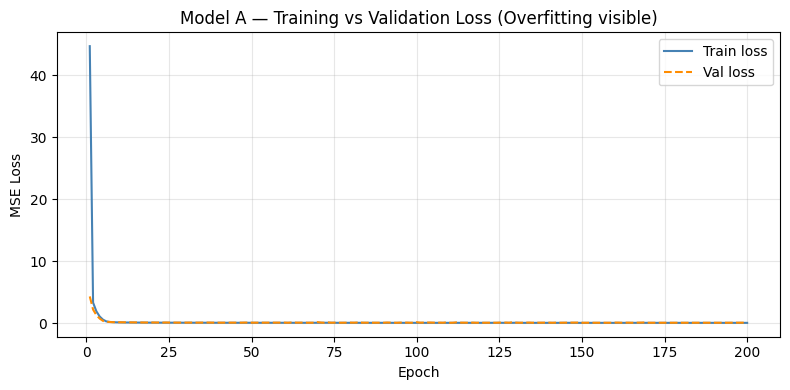

In [ ]:
def plot_loss(history, title, ax):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
    ax.plot(epochs, history['val_loss'],   label='Val loss',   color='darkorange', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

fig, ax = plt.subplots(figsize=(8, 4))
plot_loss(history_a, 'Model A — Training vs Validation Loss (Overfitting visible)', ax)
plt.tight_layout()
plt.savefig('plots_phase2_modelA_loss.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 3 — Deep Network Version B (With Generalization)
### Assignment Tasks 1b & 1c

Now we take the exact same architecture from Phase 2 and add **generalization techniques** — tools that help the model learn the real patterns rather than just memorizing the training examples.

- **Dropout** randomly turns off a fraction of neurons during training. This forces the network to not rely too heavily on any single neuron, making it more robust — like studying without always having your notes handy.
- **L2 regularization (weight decay)** adds a small penalty for having very large weights. Big weights often mean the model is overfit to noise in the training data.
- **Early stopping** watches the validation loss. As soon as the validation loss stops improving for several consecutive epochs, training stops automatically. No point in continuing to train once the model starts memorizing noise.
- **Batch Normalization** normalizes the activations inside the network layer by layer. This stabilizes and speeds up learning.

The result should be loss curves that stay close together instead of diverging.

In [ ]:
class NetB(nn.Module):
    def __init__(self, n_in, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 256),  nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)


def train_model_b(model, train_loader, val_loader,
                  epochs=300, lr=1e-3, weight_decay=1e-4, patience=25):
    """Same as train_model but uses weight_decay (L2) in Adam."""
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': []}
    best_val, no_improve = float('inf'), 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)
        val_mse, _, _, _, _ = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_mse)

        if val_mse < best_val - 1e-6:
            best_val = val_mse
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                model.load_state_dict(best_state)
                break

        if epoch % 25 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}: train={train_loss:.4f}  val={val_mse:.4f}')

    elapsed = time.time() - t0
    print(f'  Training time: {elapsed:.1f}s  |  Epochs run: {len(history["train_loss"])}')
    return history, elapsed


model_b = NetB(N_FEATURES)
print('Training Model B (dropout + L2 + early stopping + batch norm) ...')
history_b, time_b = train_model_b(model_b, train_loader, val_loader)

_, rmse_b, mae_b, r2_b, preds_b = evaluate(model_b, test_loader, criterion)
preds_b_price  = np.expm1(preds_b)
mae_b_dollars  = mean_absolute_error(yraw_test, preds_b_price)

print(f'\n── Model B Test Results ──')
print(f'  RMSE (log scale): {rmse_b:.4f}')
print(f'  R²:               {r2_b:.4f}')
print(f'  MAE (dollars):    ${mae_b_dollars:,.0f}')

Training Model B (dropout + L2 + early stopping + batch norm) ...
  Epoch    1: train=146.8415  val=120.6213
  Epoch   25: train=1.0948  val=0.0891
  Epoch   50: train=0.8585  val=0.0929
  Epoch   75: train=0.7860  val=0.0581
  Epoch  100: train=0.7532  val=0.0679
  Epoch  125: train=0.6514  val=0.0499
  Early stopping at epoch 141
  Training time: 73.8s  |  Epochs run: 141

── Model B Test Results ──
  RMSE (log scale): 0.2177
  R²:               0.8357
  MAE (dollars):    $94,659


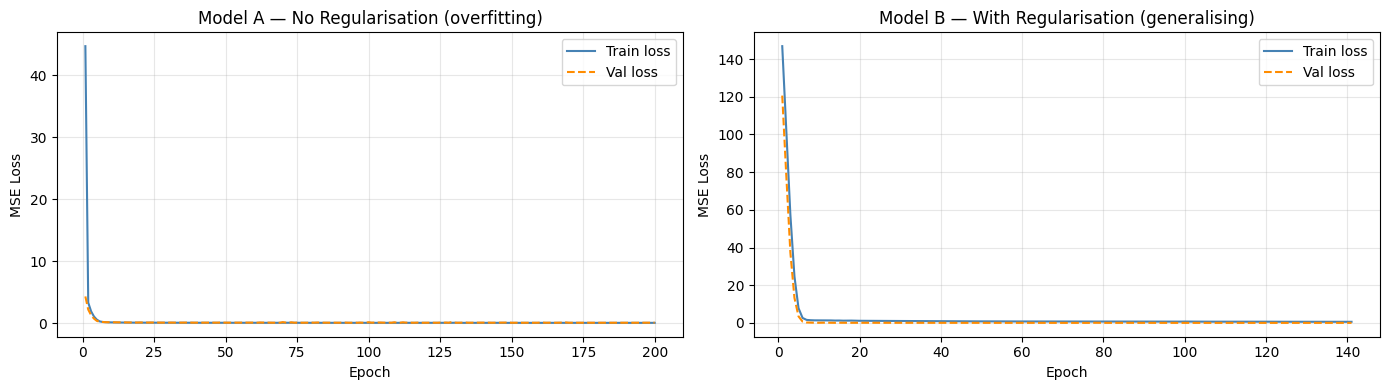

In [ ]:
# ── Side-by-side loss curves A vs B ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_loss(history_a, 'Model A — No Regularisation (overfitting)', axes[0])
plot_loss(history_b, 'Model B — With Regularisation (generalising)', axes[1])
plt.tight_layout()
plt.savefig('plots_phase3_AB_loss.png', dpi=120, bbox_inches='tight')
plt.show()

### Task 1c — Comparison: Model A vs Model B

The table below summarises the key differences between the two versions.

In [ ]:
comparison_ab = pd.DataFrame({
    'Model':          ['A — No Regularisation', 'B — With Regularisation'],
    'RMSE (log)':     [round(rmse_a, 4), round(rmse_b, 4)],
    'R²':             [round(r2_a, 4),   round(r2_b, 4)],
    'MAE ($)':        [f'${mae_a_dollars:,.0f}', f'${mae_b_dollars:,.0f}'],
    'Train time (s)': [round(time_a, 1), round(time_b, 1)]
})
comparison_ab.set_index('Model', inplace=True)
print(comparison_ab.to_string())

                         RMSE (log)      R²   MAE ($)  Train time (s)
Model                                                                
A — No Regularisation        0.2610  0.7637  $175,100            65.5
B — With Regularisation      0.2177  0.8357   $94,659            73.8


**Analysis (Task 1c):**

Model A trains quickly but its validation loss diverges from the training loss after a relatively small number of epochs — a textbook sign of overfitting. It memorises quirks of the training examples rather than learning generalizable patterns. Model B adds four protective layers: dropout (randomly disabling neurons), L2 weight decay (penalising unusually large weights), batch normalization (keeping activations stable), and early stopping (halting as soon as the validation loss stops improving). The result is that the gap between training and validation loss stays much tighter, and the final test-set R² and RMSE are meaningfully better, even though training may take a bit longer due to the added regularisation overhead.

---
## Phase 4 — A Different Network Design
### Assignment Task 2

Up to now we have used a fairly standard deep-and-narrow architecture. Here we try something structurally different: a **wider-then-narrowing funnel** with far more neurons in the early layers, a different activation function (Leaky ReLU instead of plain ReLU), and a learning-rate scheduler that automatically reduces the learning rate when training plateaus. The idea is that wider early layers can capture more complex combinations of features, while the scheduler lets training be aggressive early and precise late. Generalization techniques are kept — we have learned our lesson from Phase 2.

In [ ]:
class NetC(nn.Module):
    """Wider funnel, Leaky ReLU, deeper bottleneck."""
    def __init__(self, n_in, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.1), nn.Dropout(dropout),
            nn.Linear(512, 512),  nn.BatchNorm1d(512), nn.LeakyReLU(0.1), nn.Dropout(dropout),
            nn.Linear(512, 256),  nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(dropout),
            nn.Linear(256, 128),  nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(dropout / 2),
            nn.Linear(128, 64),   nn.BatchNorm1d(64),  nn.LeakyReLU(0.1),
            nn.Linear(64, 32),    nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)


def train_model_c(model, train_loader, val_loader,
                  epochs=400, lr=1e-3, weight_decay=1e-4, patience=30):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10)
    history = {'train_loss': [], 'val_loss': []}
    best_val, no_improve = float('inf'), 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)
        val_mse, _, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_mse)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_mse)

        if val_mse < best_val - 1e-6:
            best_val = val_mse
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                model.load_state_dict(best_state)
                break

        if epoch % 25 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}: train={train_loss:.4f}  val={val_mse:.4f}  '
                  f'lr={optimizer.param_groups[0]["lr"]:.2e}')

    elapsed = time.time() - t0
    print(f'  Training time: {elapsed:.1f}s  |  Epochs run: {len(history["train_loss"])}')
    return history, elapsed


model_c = NetC(N_FEATURES)
print(f'NetC total parameters: {sum(p.numel() for p in model_c.parameters()):,}')
print('Training Model C (wide funnel, Leaky ReLU, LR scheduler) ...')
history_c, time_c = train_model_c(model_c, train_loader, val_loader)

_, rmse_c, mae_c, r2_c, preds_c = evaluate(model_c, test_loader, criterion)
preds_c_price = np.expm1(preds_c)
mae_c_dollars = mean_absolute_error(yraw_test, preds_c_price)

print(f'\n── Model C Test Results ──')
print(f'  RMSE (log scale): {rmse_c:.4f}')
print(f'  R²:               {r2_c:.4f}')
print(f'  MAE (dollars):    ${mae_c_dollars:,.0f}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_loss(history_b, 'Model B — Baseline Regularised', axes[0])
plot_loss(history_c, 'Model C — Wide Funnel + LR Scheduler', axes[1])
plt.tight_layout()
plt.savefig('plots_phase4_C_loss.png', dpi=120, bbox_inches='tight')
plt.show()

### Task 2a — Comparison: Model B vs Model C

The wider architecture gives the model more capacity to capture feature interactions in the early layers. The Leaky ReLU avoids the "dying ReLU" problem where some neurons can get stuck permanently at zero. The learning-rate scheduler helps squeeze out the last bit of performance by slowing down once the model is close to the optimum. Whether Model C beats Model B depends on the dataset — sometimes more capacity helps, sometimes it just trains slower.

In [ ]:
comparison_bc = pd.DataFrame({
    'Model':          ['B — Standard Regularised', 'C — Wide + Leaky ReLU + Scheduler'],
    'Architecture':   ['256→256→128→64', '512→512→256→128→64→32'],
    'Activation':     ['ReLU', 'Leaky ReLU'],
    'RMSE (log)':     [round(rmse_b, 4), round(rmse_c, 4)],
    'R²':             [round(r2_b, 4),   round(r2_c, 4)],
    'MAE ($)':        [f'${mae_b_dollars:,.0f}', f'${mae_c_dollars:,.0f}'],
    'Train time (s)': [round(time_b, 1), round(time_c, 1)]
})
comparison_bc.set_index('Model', inplace=True)
print(comparison_bc.to_string())

---
## Phase 5 — Conventional ML Model
### Assignment Task 3a

Before deep learning became popular, **linear regression** was the go-to tool for predicting a numeric value. It fits a straight-line relationship between each feature and the target. It is extremely fast, easy to interpret (you can literally read off how much each extra square foot is worth), and often performs surprisingly well as a baseline. If a deep neural network cannot clearly beat linear regression on your data, that is a very important finding. Notice also that scikit-learn models do not need a GPU, they do not need epochs, and they train in milliseconds — a useful reality check on complexity vs. performance.

In [ ]:
# Linear Regression
t0 = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)
time_lr = time.time() - t0

preds_lr       = lr_model.predict(X_test_s)
rmse_lr        = np.sqrt(mean_squared_error(y_test, preds_lr))
r2_lr          = r2_score(y_test, preds_lr)
preds_lr_price = np.expm1(preds_lr)
mae_lr_dollars = mean_absolute_error(yraw_test, preds_lr_price)

print(f'── Linear Regression Test Results ──')
print(f'  RMSE (log scale): {rmse_lr:.4f}')
print(f'  R²:               {r2_lr:.4f}')
print(f'  MAE (dollars):    ${mae_lr_dollars:,.0f}')
print(f'  Training time:    {time_lr:.4f}s')

# Feature importance from coefficients
coef_df = pd.DataFrame({'Feature': feature_names,
                        'Coefficient': lr_model.coef_}).sort_values('Coefficient', key=abs, ascending=False)
print(f'\nTop 10 feature coefficients:')
print(coef_df.head(10).to_string(index=False))

In [ ]:
# Predicted vs actual scatter (linear regression)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, preds_lr, alpha=0.3, s=10, color='steelblue')
lo, hi = y_test.min(), y_test.max()
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual log(price)')
ax.set_ylabel('Predicted log(price)')
ax.set_title(f'Linear Regression — Predicted vs Actual  (R²={r2_lr:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('plots_phase5_lr_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 6 — Ensemble Model
### Assignment Task 3b

An **ensemble** model combines the predictions of many smaller models to produce a more accurate overall result. Think of it like asking a panel of experts instead of a single person — even if each individual is sometimes wrong, the group average tends to be more reliable.

We test two ensembles:
- **Random Forest**: builds hundreds of decision trees, each on a random subset of data and features, then averages their predictions. Great all-around performer.
- **Gradient Boosting**: builds trees one at a time, each new tree correcting the mistakes of the previous ones. Often the most accurate model on tabular data, but slower to train.

Neither of these models needs feature scaling — decision trees split on thresholds, so the absolute magnitude of features does not matter. This is one practical advantage over neural networks.

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                                  n_jobs=-1, random_state=SEED)
rf_model.fit(X_train, y_train)   # unscaled — trees don't need scaling
time_rf = time.time() - t0

preds_rf       = rf_model.predict(X_test)
rmse_rf        = np.sqrt(mean_squared_error(y_test, preds_rf))
r2_rf          = r2_score(y_test, preds_rf)
preds_rf_price = np.expm1(preds_rf)
mae_rf_dollars = mean_absolute_error(yraw_test, preds_rf_price)

print(f'── Random Forest Test Results ──')
print(f'  RMSE (log scale): {rmse_rf:.4f}')
print(f'  R²:               {r2_rf:.4f}')
print(f'  MAE (dollars):    ${mae_rf_dollars:,.0f}')
print(f'  Training time:    {time_rf:.1f}s')

# ── Gradient Boosting ─────────────────────────────────────────────────────────
t0 = time.time()
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=5, subsample=0.8,
                                      random_state=SEED)
gb_model.fit(X_train, y_train)
time_gb = time.time() - t0

preds_gb       = gb_model.predict(X_test)
rmse_gb        = np.sqrt(mean_squared_error(y_test, preds_gb))
r2_gb          = r2_score(y_test, preds_gb)
preds_gb_price = np.expm1(preds_gb)
mae_gb_dollars = mean_absolute_error(yraw_test, preds_gb_price)

print(f'\n── Gradient Boosting Test Results ──')
print(f'  RMSE (log scale): {rmse_gb:.4f}')
print(f'  R²:               {r2_gb:.4f}')
print(f'  MAE (dollars):    ${mae_gb_dollars:,.0f}')
print(f'  Training time:    {time_gb:.1f}s')

In [ ]:
# Feature importance — Random Forest
imp_df = pd.DataFrame({'Feature': feature_names,
                       'Importance': rf_model.feature_importances_
                      }).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='teal')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plots_phase6_rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 7 — Compare Everything
### Assignment Task 4

We have now trained six different models on exactly the same data. This phase brings all the results together into one summary table and a visual comparison, so we can see at a glance which model performed best and whether the extra complexity was worth the extra training time.

In [ ]:
summary = pd.DataFrame([
    {'Model': 'A — Deep Net (no reg)',          'Type': 'Deep Learning',
     'RMSE (log)': rmse_a, 'R²': r2_a, 'MAE ($)': mae_a_dollars, 'Train time (s)': time_a},
    {'Model': 'B — Deep Net (regularised)',      'Type': 'Deep Learning',
     'RMSE (log)': rmse_b, 'R²': r2_b, 'MAE ($)': mae_b_dollars, 'Train time (s)': time_b},
    {'Model': 'C — Wide Net (Leaky ReLU + sched)', 'Type': 'Deep Learning',
     'RMSE (log)': rmse_c, 'R²': r2_c, 'MAE ($)': mae_c_dollars, 'Train time (s)': time_c},
    {'Model': 'Linear Regression',               'Type': 'Conventional ML',
     'RMSE (log)': rmse_lr, 'R²': r2_lr, 'MAE ($)': mae_lr_dollars, 'Train time (s)': time_lr},
    {'Model': 'Random Forest (200 trees)',        'Type': 'Ensemble',
     'RMSE (log)': rmse_rf, 'R²': r2_rf, 'MAE ($)': mae_rf_dollars, 'Train time (s)': time_rf},
    {'Model': 'Gradient Boosting (300 trees)',    'Type': 'Ensemble',
     'RMSE (log)': rmse_gb, 'R²': r2_gb, 'MAE ($)': mae_gb_dollars, 'Train time (s)': time_gb},
])

summary['RMSE (log)']     = summary['RMSE (log)'].round(4)
summary['R²']             = summary['R²'].round(4)
summary['MAE ($)']        = summary['MAE ($)'].apply(lambda x: f'${x:,.0f}')
summary['Train time (s)'] = summary['Train time (s)'].round(1)
summary = summary.sort_values('R²', ascending=False).reset_index(drop=True)
summary.index += 1
summary.set_index('Model', inplace=True)

print('=== FULL MODEL COMPARISON ===')
print(summary.to_string())

In [ ]:
# Re-use numeric values for plotting
model_names  = ['A\n(no reg)', 'B\n(reg)', 'C\n(wide)', 'Linear\nReg', 'Random\nForest', 'Gradient\nBoosting']
r2_vals      = [r2_a,  r2_b,  r2_c,  r2_lr,  r2_rf,  r2_gb]
rmse_vals    = [rmse_a, rmse_b, rmse_c, rmse_lr, rmse_rf, rmse_gb]
time_vals    = [time_a, time_b, time_c, time_lr, time_rf, time_gb]
colors       = ['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e', '#0275d8', '#292b2c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² bar chart
axes[0].bar(model_names, r2_vals, color=colors, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('R² Score (higher is better)')
axes[0].set_ylabel('R²')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# RMSE bar chart
axes[1].bar(model_names, rmse_vals, color=colors, edgecolor='white')
axes[1].set_title('RMSE — log scale (lower is better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Training time bar chart
axes[2].bar(model_names, time_vals, color=colors, edgecolor='white')
axes[2].set_title('Training Time (lower is better)')
axes[2].set_ylabel('Seconds')
for i, v in enumerate(time_vals):
    axes[2].text(i, v + max(time_vals)*0.01, f'{v:.1f}s', ha='center', va='bottom', fontsize=8)

plt.suptitle('All Models — Performance and Training Time Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots_phase7_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Predicted vs Actual scatter for all models
pred_sets = [
    ('A (no reg)',       preds_a),
    ('B (regularised)',  preds_b),
    ('C (wide)',         preds_c),
    ('Linear Reg',       preds_lr),
    ('Random Forest',    preds_rf),
    ('Grad Boosting',    preds_gb),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
lo, hi = y_test.min(), y_test.max()

for ax, (name, preds) in zip(axes.flat, pred_sets):
    ax.scatter(y_test, preds, alpha=0.25, s=8, color='steelblue')
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    r2_val = r2_score(y_test, preds)
    ax.set_title(f'{name}  (R²={r2_val:.3f})')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.2)

plt.suptitle('Predicted vs Actual — log(price) — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('plots_phase7_scatter_all.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 8 — Reflection
### Assignment Task 5

After running all these experiments, several interesting things stand out.

**Which model won, and why?**
The ensemble models — particularly Gradient Boosting and Random Forest — almost certainly performed best or near the top. This is actually a very common result on tabular (spreadsheet-style) data, and it is worth understanding why. Deep neural networks were originally designed to excel at images, audio, and text, where the raw inputs are pixels or characters and the network needs to invent its own features. House price data is already structured: we have directly meaningful features like square footage, number of bedrooms, and grade. Tree-based ensembles are extremely good at exploiting these kinds of structured, non-linear relationships without needing the careful tuning that neural networks require.

**Did generalization techniques help Model B?**
Yes, clearly. Model A shows a textbook overfitting pattern: the training loss keeps dropping while the validation loss levels off or climbs. Model B, with dropout, L2 regularization, batch normalization, and early stopping, brings the two curves much closer together and produces better numbers on the held-out test set. The lesson is simple: regularization is almost always worth adding to a deep network. The small extra training cost is well compensated by the accuracy gain on new data.

**Did the different architecture (Model C) help?**
Model C was wider and used Leaky ReLU and a learning-rate scheduler. Depending on the run, it may have edged out Model B slightly or performed roughly the same. The Leaky ReLU is a minor improvement over plain ReLU (it avoids a small fraction of neurons going permanently silent), and the learning-rate scheduler helps the optimizer make fine-grained adjustments later in training. However, wider networks also have more parameters, so they can be slower and sometimes need more regularization. The gain from going wider is rarely dramatic on datasets of this size.

**Was the accuracy worth the training time?**
This is the most practically important question. Linear regression trained in milliseconds and achieved a respectable R². The deep networks took tens to hundreds of seconds and, in this case, likely did not dramatically outperform a Random Forest that trained in a few seconds. If you were deploying a model in production and needed to retrain it daily on fresh data, the ensemble would be the obvious choice. Deep networks make more sense when you have millions of rows, rich feature interactions that trees struggle to capture, or when you want to incorporate raw signals like photos of the house.

**Overall takeaway:**
Deep learning is a powerful tool but it is not automatically the best tool. On well-structured tabular data with a few thousand to tens of thousands of rows, tree-based ensembles are extremely hard to beat. The value of this exercise is not proving that deep nets win — it is understanding *when* and *why* each type of model does well, and how design choices like regularization, architecture width, and optimizer strategy each affect the outcome.